# GCN Forward Pass — Step by Step

This notebook traces a single forward pass of a Graph Convolutional Network
on a toy 5-node graph. Every matrix operation is shown explicitly so you can
see exactly what message passing does mathematically.

## The toy graph

We have 5 nodes (papers) with 3 features each, connected as follows:


## The toy graph

We have 5 nodes (papers) with 3 features each, connected as follows:

```
0 -- 1 -- 2
|         |
3 -- 4 ---+
```
Each node has a feature vector of size 3.
Goal: after 2 GCN layers, each node should have aggregated information
from its 2-hop neighbourhood.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

## Step 1 — Define the graph

We need two things:
- **X**: node feature matrix (N × F) — N nodes, F features each
- **A**: adjacency matrix (N × N) — 1 if nodes are connected, 0 otherwise

In [2]:
# Node feature matrix — 5 nodes, 3 features each
X = np.array([
    [1.0, 0.0, 1.0],   # node 0
    [0.0, 1.0, 0.0],   # node 1
    [1.0, 1.0, 0.0],   # node 2
    [0.0, 0.0, 1.0],   # node 3
    [1.0, 0.0, 0.0],   # node 4
])

# Adjacency matrix — which nodes are connected
# Edges: 0-1, 1-2, 0-3, 3-4, 2-4
A = np.array([
    [0, 1, 0, 1, 0],   # node 0 connects to 1, 3
    [1, 0, 1, 0, 0],   # node 1 connects to 0, 2
    [0, 1, 0, 0, 1],   # node 2 connects to 1, 4
    [1, 0, 0, 0, 1],   # node 3 connects to 0, 4
    [0, 0, 1, 1, 0],   # node 4 connects to 2, 3
], dtype=float)

print("Node features X:")
print(X)
print("\nAdjacency matrix A:")
print(A)

Node features X:
[[1. 0. 1.]
 [0. 1. 0.]
 [1. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]

Adjacency matrix A:
[[0. 1. 0. 1. 0.]
 [1. 0. 1. 0. 0.]
 [0. 1. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [0. 0. 1. 1. 0.]]


## Step 2 — Visualise the graph

/var/folders/x2/nz5z9_j172lfxmfwjhbz6dhh0000gn/T/ipykernel_82971/1887923864.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


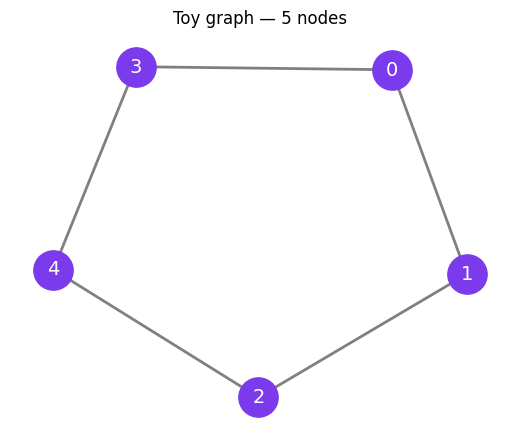

Node degrees: {0: 2, 1: 2, 2: 2, 3: 2, 4: 2}


In [3]:
G = nx.from_numpy_array(A)
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(5, 4))
nx.draw(G, pos, with_labels=True, node_color="#7C3AED",
        node_size=800, font_color="white", font_size=14,
        edge_color="gray", width=2)
plt.title("Toy graph — 5 nodes")
plt.tight_layout()
plt.show()

print("Node degrees:", dict(G.degree()))

## Step 3 — Add self-loops

In GCN, each node aggregates its OWN features too — not just its neighbours.
We do this by adding the identity matrix to A:

$$\tilde{A} = A + I$$

This ensures every node includes itself in the aggregation.

In [4]:
I = np.eye(5)
A_tilde = A + I

print("A + I (adjacency with self-loops):")
print(A_tilde)

A + I (adjacency with self-loops):
[[1. 1. 0. 1. 0.]
 [1. 1. 1. 0. 0.]
 [0. 1. 1. 0. 1.]
 [1. 0. 0. 1. 1.]
 [0. 0. 1. 1. 1.]]


## Step 4 — Normalise by degree

Without normalisation, high-degree nodes dominate the aggregation.
A node with 10 neighbours would sum 10 vectors — much larger than a node
with 2 neighbours.

GCN uses symmetric normalisation:

$$\hat{A} = D^{-1/2} \tilde{A} D^{-1/2}$$

Where D is the degree matrix (diagonal matrix of node degrees).
This scales each edge by the square root of both nodes' degrees.

In [5]:
# Degree matrix — diagonal matrix of row sums of A_tilde
degrees = A_tilde.sum(axis=1)
print("Degrees (with self-loops):", degrees)

# D^{-1/2} — inverse square root of degree matrix
D_inv_sqrt = np.diag(1.0 / np.sqrt(degrees))
print("\nD^{-1/2}:")
print(D_inv_sqrt)

# Normalised adjacency matrix
A_hat = D_inv_sqrt @ A_tilde @ D_inv_sqrt
print("\nNormalised adjacency A_hat:")
print(A_hat)

Degrees (with self-loops): [3. 3. 3. 3. 3.]

D^{-1/2}:
[[0.5774 0.     0.     0.     0.    ]
 [0.     0.5774 0.     0.     0.    ]
 [0.     0.     0.5774 0.     0.    ]
 [0.     0.     0.     0.5774 0.    ]
 [0.     0.     0.     0.     0.5774]]

Normalised adjacency A_hat:
[[0.3333 0.3333 0.     0.3333 0.    ]
 [0.3333 0.3333 0.3333 0.     0.    ]
 [0.     0.3333 0.3333 0.     0.3333]
 [0.3333 0.     0.     0.3333 0.3333]
 [0.     0.     0.3333 0.3333 0.3333]]


## Step 5 — Define weight matrices

Each GCN layer has a learnable weight matrix W.
In a real model these are learned by gradient descent.
Here we initialise them randomly to trace the forward pass.

Layer 1: maps from 3 features → 4 hidden dimensions
Layer 2: maps from 4 hidden → 2 output dimensions (2 classes)

In [6]:
np.random.seed(0)

# Layer 1: (3 features → 4 hidden)
W1 = np.random.randn(3, 4) * 0.5
print("W1 (3 → 4):")
print(W1)

# Layer 2: (4 hidden → 2 classes)
W2 = np.random.randn(4, 2) * 0.5
print("\nW2 (4 → 2):")
print(W2)

W1 (3 → 4):
[[ 0.882   0.2001  0.4894  1.1204]
 [ 0.9338 -0.4886  0.475  -0.0757]
 [-0.0516  0.2053  0.072   0.7271]]

W2 (4 → 2):
[[ 0.3805  0.0608]
 [ 0.2219  0.1668]
 [ 0.747  -0.1026]
 [ 0.1565 -0.427 ]]


## Step 6 — GCN Layer 1

The GCN layer update rule is:

$$H^{(1)} = \text{ReLU}(\hat{A} \cdot X \cdot W_1)$$

Breaking this down:
1. **X @ W1** — linear transformation of node features
2. **A_hat @ (X @ W1)** — aggregate transformed features from neighbours
3. **ReLU(...)** — non-linearity

After this layer, each node has seen its **1-hop neighbourhood**.

In [7]:
def relu(x):
    return np.maximum(0, x)

# Step 6a — linear transformation
XW1 = X @ W1
print("X @ W1 (linear transformation of features):")
print(XW1)

# Step 6b — neighbourhood aggregation
AXW1 = A_hat @ XW1
print("\nA_hat @ X @ W1 (after aggregating from neighbours):")
print(AXW1)

# Step 6c — apply ReLU
H1 = relu(AXW1)
print("\nH1 = ReLU(A_hat @ X @ W1) — output of layer 1:")
print(H1)
print("\nShape:", H1.shape, "— 5 nodes, 4 hidden dimensions")

X @ W1 (linear transformation of features):
[[ 0.8304  0.4054  0.5614  1.8476]
 [ 0.9338 -0.4886  0.475  -0.0757]
 [ 1.8158 -0.2886  0.9644  1.0448]
 [-0.0516  0.2053  0.072   0.7271]
 [ 0.882   0.2001  0.4894  1.1204]]

A_hat @ X @ W1 (after aggregating from neighbours):
[[ 0.5709  0.0407  0.3695  0.833 ]
 [ 1.1933 -0.1239  0.6669  0.9389]
 [ 1.2105 -0.1924  0.6429  0.6965]
 [ 0.5536  0.2703  0.3743  1.2317]
 [ 0.8821  0.0389  0.5086  0.9641]]

H1 = ReLU(A_hat @ X @ W1) — output of layer 1:
[[0.5709 0.0407 0.3695 0.833 ]
 [1.1933 0.     0.6669 0.9389]
 [1.2105 0.     0.6429 0.6965]
 [0.5536 0.2703 0.3743 1.2317]
 [0.8821 0.0389 0.5086 0.9641]]

Shape: (5, 4) — 5 nodes, 4 hidden dimensions


## Step 7 — Inspect what node 0 aggregated

Node 0 connects to nodes 1 and 3 (plus itself via self-loop).
Let's verify that its new embedding is a weighted combination of
its own features and its neighbours' features.

In [8]:
print("Node 0 neighbours (including self): 0, 1, 3")
print(f"\nA_hat row for node 0: {A_hat[0]}")
print("(non-zero entries show which nodes contribute and how much)")

print(f"\nContribution from node 0 (self): {A_hat[0,0]:.4f} × {XW1[0]}")
print(f"Contribution from node 1:        {A_hat[0,1]:.4f} × {XW1[1]}")
print(f"Contribution from node 3:        {A_hat[0,3]:.4f} × {XW1[3]}")

weighted_sum = (A_hat[0,0] * XW1[0] +
                A_hat[0,1] * XW1[1] +
                A_hat[0,3] * XW1[3])
print(f"\nWeighted sum:         {weighted_sum}")
print(f"H1[0] (from layer):   {AXW1[0]}")
print(f"Match: {np.allclose(weighted_sum, AXW1[0])}")

Node 0 neighbours (including self): 0, 1, 3

A_hat row for node 0: [0.3333 0.3333 0.     0.3333 0.    ]
(non-zero entries show which nodes contribute and how much)

Contribution from node 0 (self): 0.3333 × [0.8304 0.4054 0.5614 1.8476]
Contribution from node 1:        0.3333 × [ 0.9338 -0.4886  0.475  -0.0757]
Contribution from node 3:        0.3333 × [-0.0516  0.2053  0.072   0.7271]

Weighted sum:         [0.5709 0.0407 0.3695 0.833 ]
H1[0] (from layer):   [0.5709 0.0407 0.3695 0.833 ]
Match: True


## Step 8 — GCN Layer 2

$$H^{(2)} = \text{Softmax}(\hat{A} \cdot H^{(1)} \cdot W_2)$$

After layer 2, each node has seen its **2-hop neighbourhood**.
Node 0 now contains information from nodes 1 and 3 (1-hop)
AND from nodes 2 and 4 (2-hop, via node 1 and 3 respectively).

The softmax converts raw scores into class probabilities.

In [9]:
def softmax(x):
    exp_x = np.exp(x - x.max(axis=1, keepdims=True))
    return exp_x / exp_x.sum(axis=1, keepdims=True)

# Layer 2
H1W2  = H1 @ W2
AH1W2 = A_hat @ H1W2
H2    = softmax(AH1W2)

print("H2 = Softmax(A_hat @ H1 @ W2) — final output:")
print(H2)
print("\nEach row = class probabilities for one node")
print("Predicted classes:", H2.argmax(axis=1))

H2 = Softmax(A_hat @ H1 @ W2) — final output:
[[0.775  0.225 ]
 [0.7813 0.2187]
 [0.7976 0.2024]
 [0.7621 0.2379]
 [0.7829 0.2171]]

Each row = class probabilities for one node
Predicted classes: [0 0 0 0 0]


## Step 9 — Verify 2-hop neighbourhood

After 2 layers, node 0 should contain information from all nodes
within 2 hops. Let's verify by checking which nodes are reachable
in 2 steps from node 0.

In [10]:
# 2-hop reachability via matrix multiplication
two_hop = A_tilde @ A_tilde
print("2-hop reachability matrix (A_tilde^2):")
print(two_hop)
print("\nNode 0 can reach these nodes in ≤2 hops:")
reachable = np.where(two_hop[0] > 0)[0]
print(reachable)
print("→ after 2 GCN layers, node 0's embedding contains")
print("  information from ALL of these nodes")

2-hop reachability matrix (A_tilde^2):
[[3. 2. 1. 2. 1.]
 [2. 3. 2. 1. 1.]
 [1. 2. 3. 1. 2.]
 [2. 1. 1. 3. 2.]
 [1. 1. 2. 2. 3.]]

Node 0 can reach these nodes in ≤2 hops:
[0 1 2 3 4]
→ after 2 GCN layers, node 0's embedding contains
  information from ALL of these nodes


## Summary — What just happened?

Input X (5×3)
↓
[Layer 1] A_hat @ X @ W1 → ReLU     → H1 (5×4)   ← 1-hop info
↓
[Layer 2] A_hat @ H1 @ W2 → Softmax  → H2 (5×2)   ← 2-hop info
↓
Class predictions for all 5 nodes simultaneously

**Key insights:**

1. **A_hat encodes the graph** — it tells each node how much to weight
   each neighbour's contribution. High-degree nodes are down-weighted.

2. **W matrices are learned** — in a real GCN, backpropagation adjusts
   W1 and W2 so that the final embeddings separate classes.

3. **Two layers = two hops** — with k layers, each node sees k-hop
   neighbourhood. More layers ≠ always better (over-smoothing risk).

4. **All nodes are updated simultaneously** — the matrix multiplication
   A_hat @ X @ W is a single operation that updates all 5 nodes at once.
   This is why GNNs are efficient.

5. **The MLP has no A_hat** — it just does X @ W, ignoring all edges.
   That's why it performs 23pp worse on Cora.

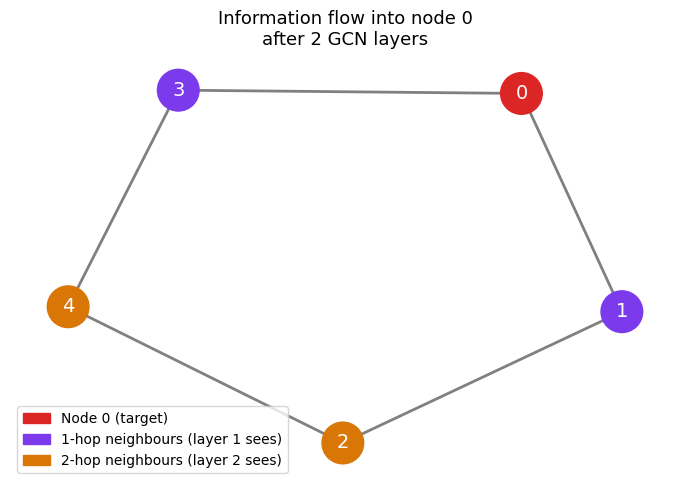

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))

G = nx.from_numpy_array(A)
pos = nx.spring_layout(G, seed=42)

# Color nodes by their role relative to node 0
node_colors = []
for n in G.nodes():
    if n == 0:
        node_colors.append("#DC2626")    # red = target node
    elif n in [1, 3]:
        node_colors.append("#7C3AED")    # purple = 1-hop neighbours
    else:
        node_colors.append("#D97706")    # amber = 2-hop neighbours

nx.draw(G, pos, ax=ax, with_labels=True,
        node_color=node_colors, node_size=900,
        font_color="white", font_size=14,
        edge_color="gray", width=2)

# Legend
from matplotlib.patches import Patch
legend = [
    Patch(color="#DC2626", label="Node 0 (target)"),
    Patch(color="#7C3AED", label="1-hop neighbours (layer 1 sees)"),
    Patch(color="#D97706", label="2-hop neighbours (layer 2 sees)"),
]
ax.legend(handles=legend, loc="lower left", fontsize=10)
ax.set_title("Information flow into node 0\nafter 2 GCN layers", fontsize=13)

plt.tight_layout()
plt.savefig("outputs/forward_pass_summary.png", dpi=150, bbox_inches="tight")
plt.show()